In [1]:
import sys, os
sys.path.append(os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'RiemannianEB', 'src'))
from utils import *
circle = Hypersphere(1)



In [ ]:
tau2 = 0.05
n_samples = 5000
rho = 1e-5
M = 10

all_num_modes =  [1, 2, 3, 4]
all_sigma2s = [0.0025, 0.01, 0.05, .1, .25, .5]

NMC = 3

In [10]:

all_records = []  # Collect all data across num_modes
for num_modes in all_num_modes:
    G_params = {'tau2': tau2/num_modes , 'num_modes': num_modes} 
    for sigma2 in all_sigma2s:
        loss_Ts, loss_Ns = [], []
        for imc in tqdm(range(NMC), desc=f'modes={num_modes}, σ²={sigma2}', leave = False ):
            Theta = S1_multimodal_prior(n_samples, G_params)
            X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
            loss_N = (circle.metric.dist_broadcast(X, Theta)**2).mean()
            delta = denoiser('S1', X, M, rho, sigma2, X, )
            loss_T = (circle.metric.dist_broadcast(delta, Theta)**2).mean() 
            loss_Ts.append(loss_T); loss_Ns.append(loss_N)
        all_records.append(pd.DataFrame({
            "num_modes": [num_modes] * NMC,
            "sigma2": [sigma2] * NMC,
            "loss_T": loss_Ts,
            "loss_N": loss_Ns
        }))

df = pd.concat(all_records, ignore_index=True)
df_long = df.melt(
    id_vars=["num_modes", "sigma2"],
    value_vars=["loss_T", "loss_N"],
    var_name="Loss Type",
    value_name="Loss"
)
df = pd.concat(all_records, ignore_index=True)


In [ ]:

all_records = []  # Collect all data across num_modes
for num_modes in all_num_modes:
    G_params = {'tau2': tau2/num_modes , 'num_modes': num_modes} 
    for sigma2 in all_sigma2s:
        loss_Ts, loss_Ns = [], []
        for imc in tqdm(range(NMC), desc=f'modes={num_modes}, σ²={sigma2}', leave = False ):
            Theta = S1_multimodal_prior(n_samples, G_params)
            X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
            loss_N = (circle.metric.dist_broadcast(X, Theta)**2).mean()
            delta = denoiser('S1', X, M, rho, sigma2, X, )
            loss_T = (circle.metric.dist_broadcast(delta, Theta)**2).mean() 
            loss_Ts.append(loss_T); loss_Ns.append(loss_N)
        all_records.append(pd.DataFrame({
            "num_modes": [num_modes] * NMC,
            "sigma2": [sigma2] * NMC,
            "loss_T": loss_Ts,
            "loss_N": loss_Ns
        }))

df = pd.concat(all_records, ignore_index=True)
df_long = df.melt(
    id_vars=["num_modes", "sigma2"],
    value_vars=["loss_T", "loss_N"],
    var_name="Loss Type",
    value_name="Loss"
)
df = pd.concat(all_records, ignore_index=True)


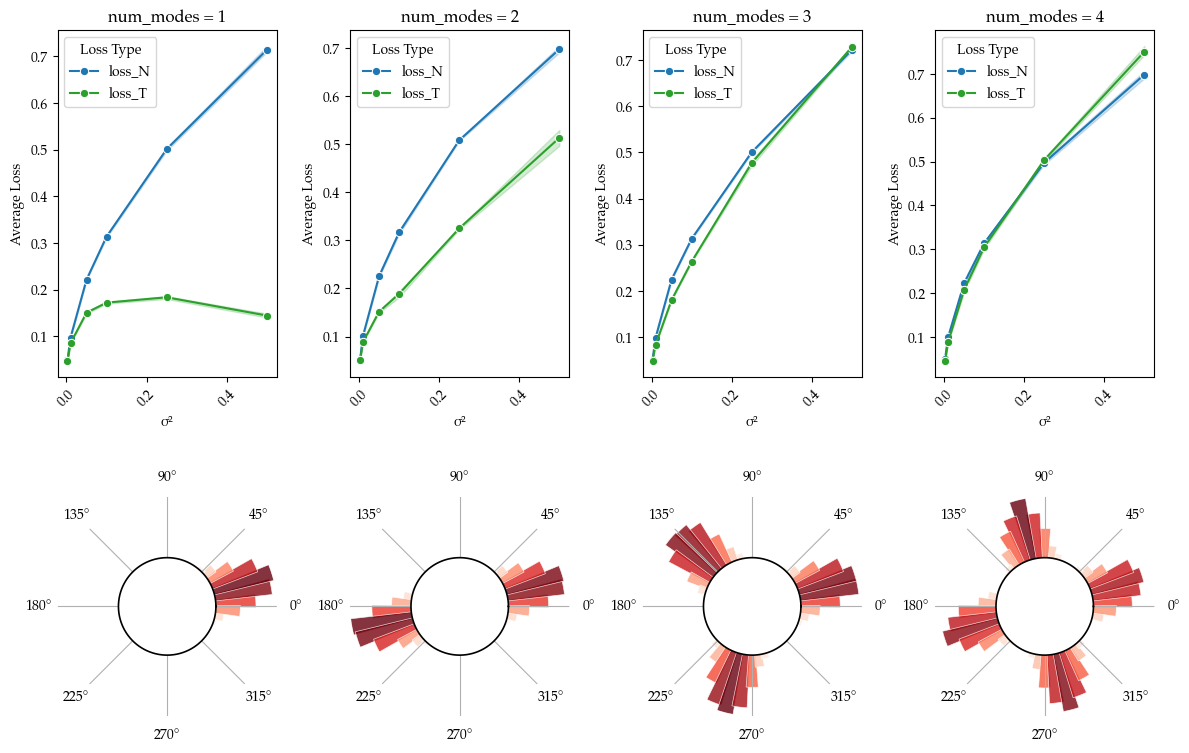

In [11]:
fig, axs = plt.subplots(2, len(all_num_modes), figsize=(12, 8))

for idx, num_modes in enumerate(all_num_modes):
    df_subset = df_long[df_long['num_modes'] == num_modes]

    sns.lineplot(
        data=df_subset,
        x="sigma2",
        y="Loss",
        hue="Loss Type",
        hue_order=["loss_N", "loss_T"],
        palette={"loss_N": "C0", "loss_T": "C2"},
        estimator="mean",
        errorbar=("ci", 68),  # 1-sigma style band; use 95 if you prefer
        marker="o",
        ax=axs[0, idx],
    )

    axs[0, idx].set_title(f"num_modes = {num_modes}")
    axs[0, idx].set_xlabel("σ²")
    axs[0, idx].set_ylabel("Average Loss")
    axs[0, idx].tick_params(axis='x', rotation=45)
    

    axs[1, idx].remove()
    axs[1, idx] = fig.add_subplot( 2, len(all_num_modes), idx + len(all_num_modes) + 1, polar=True)

    Theta = S1_multimodal_prior(  n_samples, {'tau2': tau2, 'num_modes': num_modes})
    # S1_smooth_histogram( Theta, params_to_M_dict[(num_modes, all_sigma2s[0])], axs[1, idx], 'Reds')
    S1_histogram(Theta, 50, axs[1, idx], 'Reds')

plt.tight_layout()
plt.show()

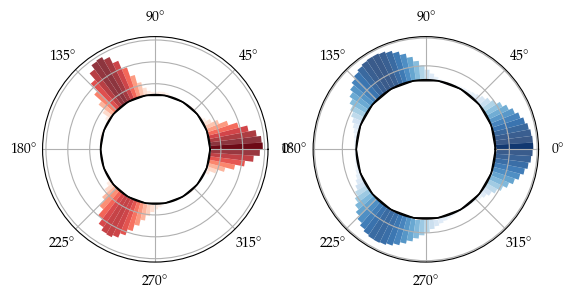

In [29]:
fig, axs = plt.subplots(1, 2, subplot_kw={'projection': 'polar'})
Theta = S1_multimodal_prior(  n_samples, {'tau2': tau2, 'num_modes': 3})
sigma2 = 1e-2
X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)

S1_smooth_histogram( Theta, params_to_M_dict[(num_modes, all_sigma2s[0])], axs[0], 'Reds')
S1_smooth_histogram( X, params_to_M_dict[(num_modes, all_sigma2s[0])], axs[1], 'Blues')





In [ ]:
fig, axs = plt.subplots(1, 2, subplot_kw={'projection': 'polar'})
Theta = S1_multimodal_prior(  n_samples, {'tau2': tau2, 'num_modes': 3})
sigma2 = 1e-2
X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)

S1_histogram(Theta, 50, axs[0], 'Reds')
S1_histogram(X, 50, axs[1], 'Blues')
